In [60]:
import numpy as np
import matplotlib.pyplot as plt
from mpdaf.obj import Cube
from astropy.coordinates import SkyCoord
import sys
import os
import plotfancy as pf
from matplotlib.patches import Circle, ConnectionPatch, FancyArrowPatch, Arrow
from astropy.visualization import ZScaleInterval

import seaborn as sns

from types import SimpleNamespace
import re
from astropy.io import ascii, fits
from astropy import units as u
from astropy.constants import c as speedoflight
from astropy.table import Table, vstack, hstack, join, Column
from scipy.optimize import curve_fit, root
from astropy.cosmology import Planck18 as cosmo
from astropy import coordinates as coords
from astroquery.sdss import SDSS
from requests.exceptions import ConnectionError
from matplotlib.lines import Line2D
# from hst_phot import *
from prospect.models.templates import TemplateLibrary
from prospect.models import SpecModel
import prospect.fitting as fitting
from prospect.io import write_results as writer
import prospect.io.read_results as reader
from prospect.sources import CSPSpecBasis
from prospect.models import priors
from genesis_metallicity.genesis_metallicity import genesis_metallicity
from mpl_toolkits.axes_grid1.inset_locator import mark_inset, zoomed_inset_axes
from tqdm import tqdm

# from calculate_jiang19_metallicity import calculate_metallicity_jiang19 as cjm19
sys.path.append('../../../')
import src.ifu_tools.line_ratios as lr
import src.ifu_tools.ifutools as ift

import logging 
logging.getLogger('mpdaf').setLevel(logging.WARNING)

import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)

In [2]:
oiilya = ascii.read('oii_lya_candidates.csv')
oiilya['obs'] = oiilya['id']
positions = SkyCoord(oiilya['ra'], oiilya['dec'], unit=(u.hourangle,u.deg))
oiilya['ra.deg'] = positions.ra.deg
oiilya['dec.deg'] = positions.dec.deg
oiilya['id'] = [p.replace('.','p').replace(' ','') for p in positions.to_string('hmsdms', sep=('h','m', 's'), pad=True)]

In [3]:
name = oiilya['cluster']
namefmt = Column([n.lower().replace('-','m').replace('+','p') for n in name])
oiilya['fpath'] = '/Volumes/Expansion/exp_thardy/cubes/'+namefmt+'_COMBINED_CUBE_MED_FINAL.fits'

lya_spec = {}
oii_spec = {}

subcubes = {}

groups = oiilya.group_by('cluster').groups
for g in tqdm(groups):

    fname = g['fpath'][0]
    cube = Cube(fname)

    for s in tqdm(g):
        obj_coord = SkyCoord(s['ra.deg'], s['dec.deg'], unit=u.deg)
        spectrum = cube.aperture(center=(obj_coord.dec.deg,obj_coord.ra.deg), radius=1)

        subcubes.update({s['id']:cube.subcube(center=(obj_coord.dec.deg,obj_coord.ra.deg), size=10)})

        if s['type'] == 'OII':
            oii_spec.update({s['id']:spectrum})

        if s['type'] == 'Lya':
            lya_spec.update({s['id']:spectrum})

100%|██████████| 5/5 [14:43<00:00, 176.79s/it]


In [4]:
oiilya['lambda'] = ((oiilya['type']=='Lya')*1215.67)+(((oiilya['type']=='OII')*3727.5))
oiilya['z'] = (oiilya['obs']/oiilya['lambda'])-1
oiilya.sort('z',reverse=True)

groups2 = oiilya.group_by('type').groups

lyacands = groups2[0][:4]
mask = (np.arange(0,20)==0)|(np.arange(0,20)==5)|(np.arange(0,20)==7)|(np.arange(0,20)==10)
oiicands = groups2[1][mask]

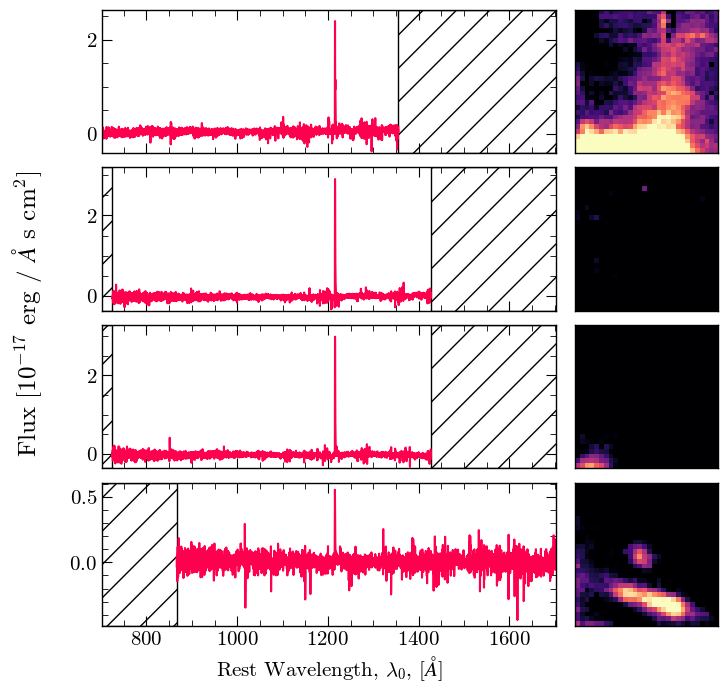

In [5]:
fig, axes_grid = plt.subplots(4,2,
                              figsize=(8,8), 
                              sharex='col',
                              gridspec_kw={'width_ratios': [3, 1]})
axes = axes_grid[:,0].flatten()
contaxes = axes_grid[:,1].flatten()

for c in contaxes:
    c.set_xticks([])
    c.set_yticks([])

axes[-1].set_xlabel(r'Rest Wavelength, $\lambda_0$, [$\AA$]')
fig.supylabel(r'Flux $[10^{-17}$ erg / $\AA$ s cm$^2]$', x=+.01)
plt.subplots_adjust(hspace=0.1, wspace=0.05)

for i,l in enumerate(lyacands):
    spectrum = lya_spec[l['id']]
    subcube = subcubes[l['id']]
    image = np.sum(subcube.data,axis=0)
    freq = spectrum.wave.coord()/(1+l['z'])

    scaler = 1.1
    max = scaler*np.max(spectrum.data/1000)
    min = scaler*np.min(spectrum.data/1000)

    axes[i].plot(freq, spectrum.data/1000, color='#ff004f')
    contaxes[i].imshow(image[10:40,10:40], vmin=100, vmax=5000, cmap='magma')

    axes[i].fill_betweenx([min,max], 0, freq[0],facecolor='white', edgecolor='black', hatch='/')
    axes[i].fill_betweenx([min,max], freq[-1],9000,facecolor='white', edgecolor='black', hatch='/')

    axes[i].set_ylim(min,max)

axes[0].set_xlim([702,1702])

pf.fix_plot(axes)
fig.savefig(f'figs/lyaspec.png', dpi=600, bbox_inches='tight')

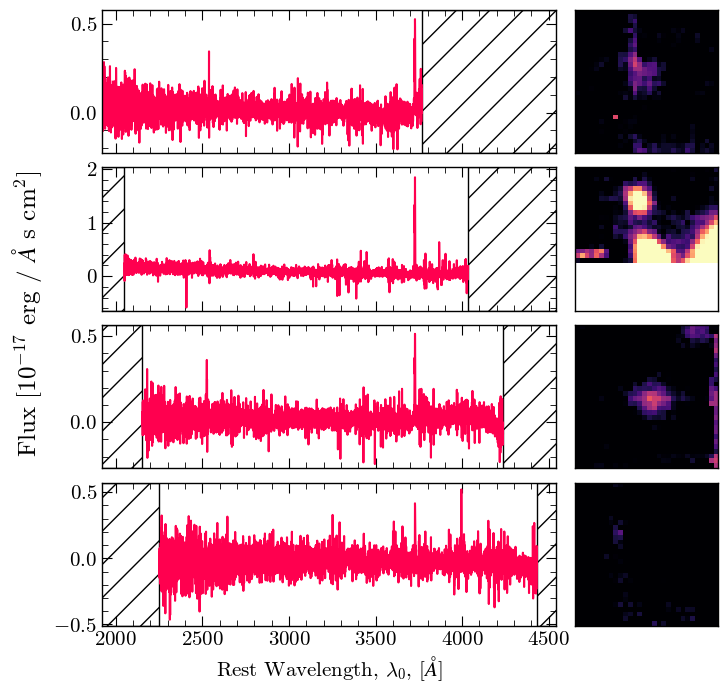

In [6]:
fig, axes_grid = plt.subplots(4,2,
                              figsize=(8,8), 
                              sharex='col',
                              gridspec_kw={'width_ratios': [3, 1]})
axes = axes_grid[:,0].flatten()
contaxes = axes_grid[:,1].flatten()

for c in contaxes:
    c.set_xticks([])
    c.set_yticks([])

axes[-1].set_xlabel(r'Rest Wavelength, $\lambda_0$, [$\AA$]')
fig.supylabel(r'Flux $[10^{-17}$ erg / $\AA$ s cm$^2]$', x=+.01)
plt.subplots_adjust(hspace=0.1, wspace=0.05)

for i,l in enumerate(oiicands):
    spectrum = oii_spec[l['id']]
    subcube = subcubes[l['id']]
    image = np.sum(subcube.data,axis=0)
    freq = spectrum.wave.coord()/(1+l['z'])

    scaler = 1.1
    max = scaler*np.max(spectrum.data/1000)
    min = scaler*np.min(spectrum.data/1000)

    axes[i].plot(freq, spectrum.data/1000, color='#ff004f')
    contaxes[i].imshow(image[10:40,10:40], vmin=100, vmax=5000, cmap='magma')

    axes[i].fill_betweenx([min,max], 0, freq[0],facecolor='white', edgecolor='black', hatch='/')
    axes[i].fill_betweenx([min,max], freq[-1],9000,facecolor='white', edgecolor='black', hatch='/')

    axes[i].set_ylim(min,max)

axes[0].set_xlim([1920,4540])

pf.fix_plot(axes)
fig.savefig(f'figs/oiispec.png', dpi=600, bbox_inches='tight')

In [ ]:
master_lya = []

common_rest_wave = np.arange(700, 1700, 2)

for s in lya_spec:
    spec = lya_spec[s]
    z = groups2[0][groups2[0]['id']==s]['z']
    resp = spec.resample(2,4800)
    freq = resp.wave.coord()
    rest_wave = freq / (1 + z)
    resampled_flux = np.interp(common_rest_wave, rest_wave,resp.data)

    median = np.abs(np.ma.median(resp.data))

    master_lya.append(resampled_flux/median)

master_lya = np.array(master_lya)
stack = np.sum(master_lya,axis=0)

fig, ax = pf.create_plot((6,3))

ax.plot(common_rest_wave,stack/100, lw=2, color='#ff004f')
ax.set_ylabel('Arbitrary Flux')
ax.set_xlabel(r'Rest Wavelength, $\lambda_0$, [$\AA$]')

pf.fix_plot([ax])
fig.savefig(f'figs/lyacoadd.png', dpi=600, bbox_inches='tight')

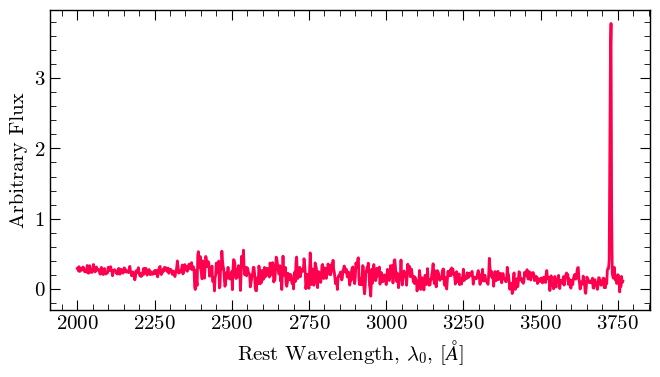

In [57]:
master_oii = []

common_rest_wave = np.arange(2000, 4500, 2)

for s in oii_spec:
    spec = oii_spec[s]
    z = groups2[1][groups2[1]['id']==s]['z']
    resp = spec.resample(2,4800)
    freq = resp.wave.coord()
    rest_wave = freq / (1 + z)
    resampled_flux = np.interp(common_rest_wave, rest_wave,resp.data)

    median = np.abs(np.ma.median(resp.data))

    master_oii.append(resampled_flux/median)

master_oii = np.array(master_oii)
stack = np.sum(master_oii,axis=0)

fig, ax = pf.create_plot((6,3))

ax.plot(common_rest_wave,stack/100, lw=2, color='#ff004f')
ax.set_ylabel('Arbitrary Flux')
ax.set_xlabel(r'Rest Wavelength, $\lambda_0$, [$\AA$]')

pf.fix_plot([ax])
fig.savefig(f'figs/oiicoadd.png', dpi=600, bbox_inches='tight')

In [58]:
def count_neighbors(target_galaxies, parent_sample, search_radius_mpc, z_window):
    """
    Counts the number of neighboring galaxies for each target galaxy.

    Parameters:
    - target_galaxies (astropy.table.Table): Table with 'RA', 'DEC', 'Z' for the target sample.
    - parent_sample (astropy.table.Table): Table with 'RA', 'DEC', 'Z' for the parent sample.
    - search_radius_mpc (float): The physical search radius in Megaparsecs at the redshift of the target.
    - z_window (float): The half-width of the redshift slice to search within (e.g., 0.01).

    Returns:
    - numpy.ndarray: An array containing the number of neighbors for each target galaxy.
    """
    neighbor_counts = []

    # Create SkyCoord objects for the entire parent sample for efficient matching
    parent_coords = SkyCoord(parent_sample['RA']*u.deg, parent_sample['DEC']*u.deg, frame='icrs')

    for target in target_galaxies:
        target_z = target['Z']
        target_coord = SkyCoord(target['RA']*u.deg, target['DEC']*u.deg, frame='icrs')

        # --- Step 1: Redshift Slice ---
        # Select galaxies from the parent sample within the redshift window
        z_min = target_z - z_window
        z_max = target_z + z_window
        in_z_slice = (parent_sample['Z'] > z_min) & (parent_sample['Z'] < z_max)
        
        # --- Step 2: Angular Search ---
        # Calculate the angular separation on the sky for galaxies in the redshift slice
        separations = target_coord.separation(parent_coords[in_z_slice])

        # --- Step 3: Count Neighbors ---
        # Count how many of those galaxies are within the search radius
        # Note: We subtract 1 to exclude the target galaxy itself from its own neighbor count
        count = np.sum(separations < separations.max()) - 1
        neighbor_counts.append(count)

    return np.array(neighbor_counts)

In [59]:
parent_sample = ascii.read('../week5/final_table.csv')
target_data = parent_sample[parent_sample['WFoiii5007_ew']>100]


# 2. Set search parameters
SEARCH_RADIUS_DEG = 0.05  # Search radius in degrees (approx 1.2 arcmin)
REDSHIFT_WINDOW = 0.01    # Redshift slice is z_target +/- 0.01

# 3. Run the analysis
counts = count_neighbors(target_data, parent_sample, SEARCH_RADIUS_DEG, REDSHIFT_WINDOW)

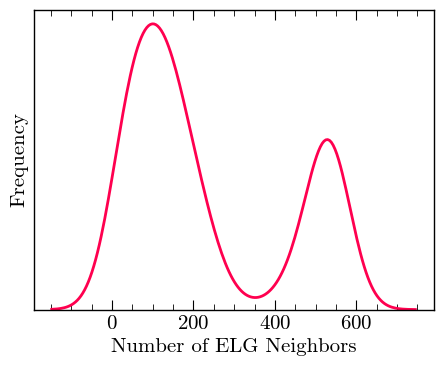

In [75]:
fig, ax = pf.create_plot()
sns.kdeplot(x=counts, color='#ff004f', lw=2)

ax.set_xlabel('Number of ELG Neighbors')
ax.set_ylabel('Frequency')
ax.set_yticks([])

pf.fix_plot([ax])
fig.savefig(f'figs/neighbors1.png', dpi=600, bbox_inches='tight')

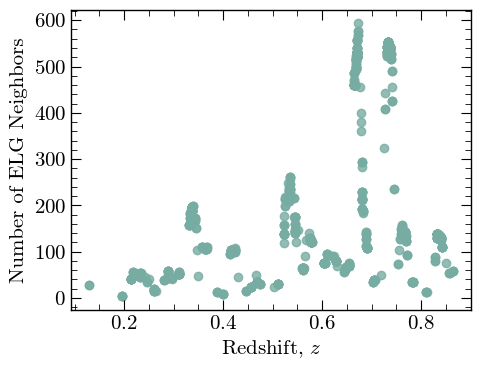

In [72]:
fig, ax = pf.create_plot()

ax.scatter(target_data['Z'], counts, color='#77aca2', alpha=0.8)
ax.set_ylabel('Number of ELG Neighbors')
ax.set_xlabel('Redshift, $z$')


pf.fix_plot([ax])
fig.savefig(f'figs/neighbors2.png', dpi=600, bbox_inches='tight')